<a href="https://colab.research.google.com/github/DavidCM28/Proyecto_MachineLearning/blob/main/Clasificacion/clasificacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fase 2. Separación de variables

In [17]:
datos = pd.read_csv("/content/data/alumnos.csv")

datos.head()

,Promedio_Parcial,Asistencia,Horas_Estudio,Accesos_Moodle,Tareas,Calificacion_Final,Resultado
0,92,81,6.2,40,9,90,Aprueba
1,56,100,12.4,30,7,78,Aprueba
2,57,78,3.4,23,7,67,Reprueba
3,52,83,6.4,35,7,73,Aprueba
4,87,85,9.3,33,10,96,Aprueba


In [18]:
variables_entrada = [
    "Promedio_Parcial",
    "Asistencia",
    "Horas_Estudio",
    "Accesos_Moodle",
    "Tareas"
]

X_clasificacion = datos[variables_entrada]
y_clasificacion = datos["Resultado"]


In [19]:
print("Entradas para clasificación:")
display(X_clasificacion.head())

print("Objetivo de clasificación:")
display(y_clasificacion.head())


Entradas para clasificación:


,Promedio_Parcial,Asistencia,Horas_Estudio,Accesos_Moodle,Tareas
0,92,81,6.2,40,9
1,56,100,12.4,30,7
2,57,78,3.4,23,7
3,52,83,6.4,35,7
4,87,85,9.3,33,10


Objetivo de clasificación:


,Resultado
0,Aprueba
1,Aprueba
2,Reprueba
3,Aprueba
4,Aprueba


# Fase 4. Implementación de los modelos


In [ ]:
# 1. Importar librerías adicionales

In [22]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline # Corrected import for Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

from sklearn.inspection import permutation_importance

In [ ]:
# Transformar Resultado

In [23]:
y_clasificacion_numerica = datos["Resultado"].map({
    "Aprueba": 1,
    "Reprueba": 0
})

print(y_clasificacion_numerica.value_counts())

Resultado
1    120
0     80
Name: count, dtype: int64


In [ ]:
# Dividir los datos

In [24]:
X_train_clasificacion, X_test_clasificacion, y_train_clasificacion, y_test_clasificacion = train_test_split(
    X_clasificacion,
    y_clasificacion_numerica,
    test_size=0.20,
    random_state=42,
    stratify=y_clasificacion_numerica
)

print("Clasificación:")
print("Entrenamiento:", X_train_clasificacion.shape)
print("Prueba:", X_test_clasificacion.shape)


Clasificación:
Entrenamiento: (160, 5)
Prueba: (40, 5)


In [ ]:
# Entrenar clasificación

In [25]:
modelo_logistico = LogisticRegression(max_iter=1000)

modelo_arbol_clasificacion = DecisionTreeClassifier(
    random_state=42
)

modelo_random_forest_clasificacion = RandomForestClassifier(
    random_state=42
)

modelo_logistico.fit(
    X_train_clasificacion,
    y_train_clasificacion
)

modelo_arbol_clasificacion.fit(
    X_train_clasificacion,
    y_train_clasificacion
)

modelo_random_forest_clasificacion.fit(
    X_train_clasificacion,
    y_train_clasificacion
)

print("Modelos de clasificación entrenados correctamente.")

Modelos de clasificación entrenados correctamente.


In [ ]:
# Generar predicciones

In [26]:
pred_logistico = modelo_logistico.predict(X_test_clasificacion)

pred_arbol_clasificacion = modelo_arbol_clasificacion.predict(
    X_test_clasificacion
)

pred_random_forest_clasificacion = modelo_random_forest_clasificacion.predict(
    X_test_clasificacion
)

print("Predicciones generadas correctamente.")

Predicciones generadas correctamente.


In [ ]:
# Mostrar ejemplos

In [27]:
comparacion_clasificacion = pd.DataFrame({
    "Resultado_real": y_test_clasificacion.values,
    "Regresion_Logistica": pred_logistico,
    "Arbol_Decision": pred_arbol_clasificacion,
    "Random_Forest": pred_random_forest_clasificacion
})

display(comparacion_clasificacion.head(10))

,Resultado_real,Regresion_Logistica,Arbol_Decision,Random_Forest
0,0,0,0,0
1,1,1,1,1
2,1,1,0,0
3,1,1,1,1
4,0,0,0,0
5,0,0,0,0
6,1,1,1,1
7,1,1,1,1
8,0,0,0,0
9,0,0,0,0


# Fase 5. Evaluación de los modelos

In [ ]:
# Calcular métricas de clasificación

In [28]:
resultados_clasificacion = []

modelos_clasificacion = {
    "Regresión Logística": pred_logistico,
    "Árbol de Decisión": pred_arbol_clasificacion,
    "Random Forest": pred_random_forest_clasificacion
}

for nombre, predicciones in modelos_clasificacion.items():
    accuracy = accuracy_score(y_test_clasificacion, predicciones)
    precision = precision_score(y_test_clasificacion, predicciones)
    recall = recall_score(y_test_clasificacion, predicciones)
    f1 = f1_score(y_test_clasificacion, predicciones)

    resultados_clasificacion.append({
        "Algoritmo": nombre,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })

tabla_clasificacion = pd.DataFrame(resultados_clasificacion)

tabla_clasificacion[
    ["Accuracy", "Precision", "Recall", "F1-score"]
] = tabla_clasificacion[
    ["Accuracy", "Precision", "Recall", "F1-score"]
].round(4)

display(tabla_clasificacion)

,Algoritmo,Accuracy,Precision,Recall,F1-score
0,Regresión Logística,0.925,0.9565,0.9167,0.9362
1,Árbol de Decisión,0.900,1.0000,0.8333,0.9091
2,Random Forest,0.900,0.9545,0.8750,0.9130


In [ ]:
# Identificar el mejor modelo de clasificación

In [29]:
mejor_clasificacion = tabla_clasificacion.loc[
    tabla_clasificacion["F1-score"].idxmax()
]

print("Mejor modelo de clasificación según F1-score:")
display(mejor_clasificacion.to_frame().T)

Mejor modelo de clasificación según F1-score:


,Algoritmo,Accuracy,Precision,Recall,F1-score
0,Regresión Logística,0.925,0.9565,0.9167,0.9362


In [ ]:
# Mostrar matrices de confusión

In [30]:
for nombre, predicciones in modelos_clasificacion.items():
    matriz = confusion_matrix(
        y_test_clasificacion,
        predicciones
    )

    print(f"Matriz de confusión - {nombre}")
    print(matriz)
    print()

Matriz de confusión - Regresión Logística
[[15  1]
 [ 2 22]]

Matriz de confusión - Árbol de Decisión
[[16  0]
 [ 4 20]]

Matriz de confusión - Random Forest
[[15  1]
 [ 3 21]]



In [ ]:
# Graficar la matriz del mejor modelo

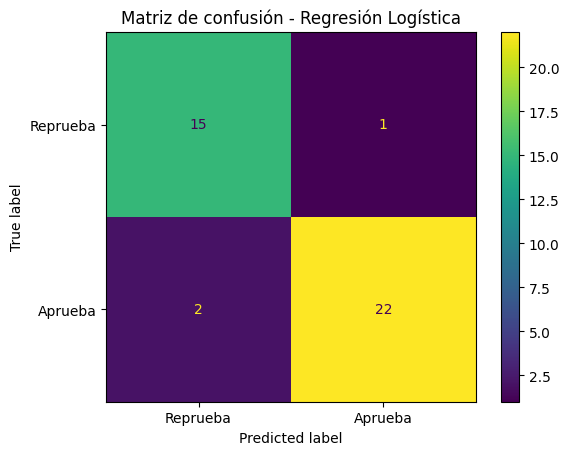

In [31]:
from sklearn.metrics import ConfusionMatrixDisplay

nombre_mejor_clasificacion = mejor_clasificacion["Algoritmo"]

predicciones_mejor_clasificacion = modelos_clasificacion[
    nombre_mejor_clasificacion
]

ConfusionMatrixDisplay.from_predictions(
    y_test_clasificacion,
    predicciones_mejor_clasificacion,
    display_labels=["Reprueba", "Aprueba"]
)

plt.title(
    f"Matriz de confusión - {nombre_mejor_clasificacion}"
)

plt.show()

# Fase 6. Optimización de los modelos

In [ ]:
# Optimizar Regresión Logística

In [32]:
pipeline_logistico = Pipeline([
    ("escalador", StandardScaler()),
    ("modelo", LogisticRegression(max_iter=2000))
])

parametros_logistico = {
    "modelo__C": [0.01, 0.1, 1, 10, 100],
    "modelo__solver": ["liblinear", "lbfgs"]
}

busqueda_logistica = GridSearchCV(
    estimator=pipeline_logistico,
    param_grid=parametros_logistico,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

busqueda_logistica.fit(
    X_train_clasificacion,
    y_train_clasificacion
)

mejor_logistico = busqueda_logistica.best_estimator_

print("Mejores parámetros de Regresión Logística:")
print(busqueda_logistica.best_params_)
print("Mejor F1 en validación cruzada:")
print(round(busqueda_logistica.best_score_, 4))

Mejores parámetros de Regresión Logística:
{'modelo__C': 0.1, 'modelo__solver': 'lbfgs'}
Mejor F1 en validación cruzada:
0.9291


In [ ]:
# Optimizar Árbol de Decisión para clasificación

In [33]:
parametros_arbol_clasificacion = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 3, 5, 7, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

busqueda_arbol_clasificacion = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=parametros_arbol_clasificacion,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

busqueda_arbol_clasificacion.fit(
    X_train_clasificacion,
    y_train_clasificacion
)

mejor_arbol_clasificacion = busqueda_arbol_clasificacion.best_estimator_

print("Mejores parámetros del Árbol de Decisión:")
print(busqueda_arbol_clasificacion.best_params_)
print("Mejor F1 en validación cruzada:")
print(round(busqueda_arbol_clasificacion.best_score_, 4))

Mejores parámetros del Árbol de Decisión:
{'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Mejor F1 en validación cruzada:
0.915


In [ ]:
# Optimizar Random Forest para clasificación

In [34]:
parametros_random_forest_clasificacion = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

busqueda_random_forest_clasificacion = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=parametros_random_forest_clasificacion,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

busqueda_random_forest_clasificacion.fit(
    X_train_clasificacion,
    y_train_clasificacion
)

mejor_random_forest_clasificacion = (
    busqueda_random_forest_clasificacion.best_estimator_
)

print("Mejores parámetros de Random Forest:")
print(busqueda_random_forest_clasificacion.best_params_)
print("Mejor F1 en validación cruzada:")
print(round(busqueda_random_forest_clasificacion.best_score_, 4))

Mejores parámetros de Random Forest:
{'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
Mejor F1 en validación cruzada:
0.9334


In [ ]:
# Generar nuevas predicciones de clasificación

In [35]:
pred_logistico_optimizado = mejor_logistico.predict(
    X_test_clasificacion
)

pred_arbol_clasificacion_optimizado = (
    mejor_arbol_clasificacion.predict(
        X_test_clasificacion
    )
)

pred_random_forest_clasificacion_optimizado = (
    mejor_random_forest_clasificacion.predict(
        X_test_clasificacion
    )
)

print("Predicciones optimizadas de clasificación generadas.")

Predicciones optimizadas de clasificación generadas.


In [ ]:
# Comparar clasificación antes y después

In [36]:
comparacion_clasificacion_optimizacion = pd.DataFrame([
    {
        "Modelo": "Regresión Logística",
        "Accuracy antes": accuracy_score(
            y_test_clasificacion,
            pred_logistico
        ),
        "Accuracy después": accuracy_score(
            y_test_clasificacion,
            pred_logistico_optimizado
        ),
        "F1 antes": f1_score(
            y_test_clasificacion,
            pred_logistico
        ),
        "F1 después": f1_score(
            y_test_clasificacion,
            pred_logistico_optimizado
        )
    },
    {
        "Modelo": "Árbol de Decisión",
        "Accuracy antes": accuracy_score(
            y_test_clasificacion,
            pred_arbol_clasificacion
        ),
        "Accuracy después": accuracy_score(
            y_test_clasificacion,
            pred_arbol_clasificacion_optimizado
        ),
        "F1 antes": f1_score(
            y_test_clasificacion,
            pred_arbol_clasificacion
        ),
        "F1 después": f1_score(
            y_test_clasificacion,
            pred_arbol_clasificacion_optimizado
        )
    },
    {
        "Modelo": "Random Forest",
        "Accuracy antes": accuracy_score(
            y_test_clasificacion,
            pred_random_forest_clasificacion
        ),
        "Accuracy después": accuracy_score(
            y_test_clasificacion,
            pred_random_forest_clasificacion_optimizado
        ),
        "F1 antes": f1_score(
            y_test_clasificacion,
            pred_random_forest_clasificacion
        ),
        "F1 después": f1_score(
            y_test_clasificacion,
            pred_random_forest_clasificacion_optimizado
        )
    }
])

columnas_clasificacion = [
    "Accuracy antes",
    "Accuracy después",
    "F1 antes",
    "F1 después"
]

comparacion_clasificacion_optimizacion[
    columnas_clasificacion
] = comparacion_clasificacion_optimizacion[
    columnas_clasificacion
].round(4)

display(comparacion_clasificacion_optimizacion)

,Modelo,Accuracy antes,Accuracy después,F1 antes,F1 después
0,Regresión Logística,0.925,0.825,0.9362,0.8444
1,Árbol de Decisión,0.900,0.900,0.9091,0.9091
2,Random Forest,0.900,0.900,0.9130,0.9130


In [ ]:
# Comparar entrenamiento y prueba en clasificación

In [37]:
modelos_optimizados_clasificacion = {
    "Regresión Logística": mejor_logistico,
    "Árbol de Decisión": mejor_arbol_clasificacion,
    "Random Forest": mejor_random_forest_clasificacion
}

sobreajuste_clasificacion = []

for nombre, modelo in modelos_optimizados_clasificacion.items():
    pred_train = modelo.predict(
        X_train_clasificacion
    )

    pred_test = modelo.predict(
        X_test_clasificacion
    )

    accuracy_train = accuracy_score(
        y_train_clasificacion,
        pred_train
    )

    accuracy_test = accuracy_score(
        y_test_clasificacion,
        pred_test
    )

    sobreajuste_clasificacion.append({
        "Modelo": nombre,
        "Accuracy entrenamiento": accuracy_train,
        "Accuracy prueba": accuracy_test,
        "Diferencia": accuracy_train - accuracy_test
    })

tabla_sobreajuste_clasificacion = pd.DataFrame(
    sobreajuste_clasificacion
)

columnas = [
    "Accuracy entrenamiento",
    "Accuracy prueba",
    "Diferencia"
]

tabla_sobreajuste_clasificacion[columnas] = (
    tabla_sobreajuste_clasificacion[columnas].round(4)
)

display(tabla_sobreajuste_clasificacion)

,Modelo,Accuracy entrenamiento,Accuracy prueba,Diferencia
0,Regresión Logística,0.9125,0.825,0.0875
1,Árbol de Decisión,0.9875,0.900,0.0875
2,Random Forest,0.9688,0.900,0.0687


# Fase 7. Resultados finales

In [ ]:
# Definir los modelos finales

In [38]:
modelo_final_clasificacion = mejor_logistico

print("Modelo final de clasificación: Regresión Logística")

Modelo final de clasificación: Regresión Logística


In [ ]:
# Crear la tabla final de modelos

In [39]:
tabla_modelos_finales = pd.DataFrame([
    {
        "Problema": "Clasificación",
        "Modelo seleccionado": "Regresión Logística",
        "Métrica principal": "F1-score",
        "Resultado": busqueda_logistica.best_score_,
        "Métrica adicional": "Accuracy",
        "Resultado adicional": accuracy_score(y_test_clasificacion, mejor_logistico.predict(X_test_clasificacion))
    }
])

display(tabla_modelos_finales)

,Problema,Modelo seleccionado,Métrica principal,Resultado,Métrica adicional,Resultado adicional
0,Clasificación,Regresión Logística,F1-score,0.929093,Accuracy,0.825


Análisis de variables importantes

In [ ]:
# Importancia de variables en clasificación

In [40]:
importancia_clasificacion = permutation_importance(
    modelo_final_clasificacion,
    X_test_clasificacion,
    y_test_clasificacion,
    scoring="f1",
    n_repeats=30,
    random_state=42
)

tabla_importancia_clasificacion = pd.DataFrame({
    "Variable": variables_entrada,
    "Importancia": importancia_clasificacion.importances_mean
}).sort_values(
    by="Importancia",
    ascending=False
).reset_index(drop=True)

tabla_importancia_clasificacion["Importancia"] = (
    tabla_importancia_clasificacion["Importancia"].round(4)
)

display(tabla_importancia_clasificacion)

,Variable,Importancia
0,Promedio_Parcial,0.0128
1,Tareas,-0.0195
2,Asistencia,-0.0292
3,Horas_Estudio,-0.0405
4,Accesos_Moodle,-0.0478


In [ ]:
# Gráfica de clasificación

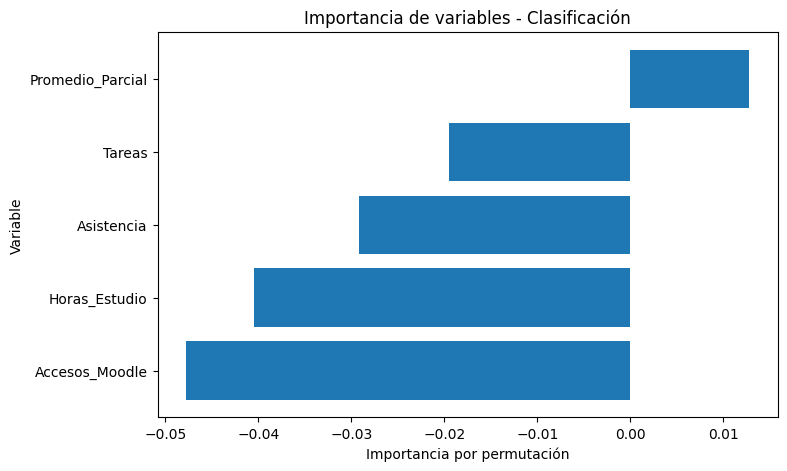

In [41]:
plt.figure(figsize=(8, 5))

plt.barh(
    tabla_importancia_clasificacion["Variable"],
    tabla_importancia_clasificacion["Importancia"]
)

plt.xlabel("Importancia por permutación")
plt.ylabel("Variable")
plt.title("Importancia de variables - Clasificación")
plt.gca().invert_yaxis()
plt.show()

Predicciones finales de ejemplo

In [ ]:
# Ejemplos del modelo de clasificación

In [42]:
probabilidad_aprobar = modelo_final_clasificacion.predict_proba(
    X_test_clasificacion
)[:, 1]

probabilidad_reprobar = 1 - probabilidad_aprobar

prediccion_final_clasificacion = modelo_final_clasificacion.predict(
    X_test_clasificacion
)

ejemplos_clasificacion = X_test_clasificacion.copy()

ejemplos_clasificacion["Resultado_real"] = (
    y_test_clasificacion
    .map({1: "Aprueba", 0: "Reprueba"})
    .values
)

ejemplos_clasificacion["Prediccion"] = pd.Series(
    prediccion_final_clasificacion
).map({
    1: "Aprueba",
    0: "Reprueba"
}).values

ejemplos_clasificacion["Probabilidad_Reprobar"] = (
    probabilidad_reprobar * 100
).round(2)

display(
    ejemplos_clasificacion[
        [
            "Promedio_Parcial",
            "Asistencia",
            "Tareas",
            "Resultado_real",
            "Prediccion",
            "Probabilidad_Reprobar"
        ]
    ].head(10)
)

,Promedio_Parcial,Asistencia,Tareas,Resultado_real,Prediccion,Probabilidad_Reprobar
150,26,53,0,Reprueba,Reprueba,99.82
0,92,81,9,Aprueba,Aprueba,6.07
70,54,78,9,Aprueba,Aprueba,30.17
54,88,93,10,Aprueba,Aprueba,1.96
179,54,79,5,Reprueba,Reprueba,77.27
16,51,75,0,Reprueba,Reprueba,98.62
10,76,100,10,Aprueba,Aprueba,1.56
178,71,82,7,Aprueba,Reprueba,55.85
99,50,67,3,Reprueba,Reprueba,91.30
131,59,64,8,Reprueba,Reprueba,61.15


In [ ]:
# Estudiantes con mayor riesgo

In [43]:
estudiantes_riesgo = ejemplos_clasificacion.sort_values(
    by="Probabilidad_Reprobar",
    ascending=False
)

display(
    estudiantes_riesgo[
        [
            "Promedio_Parcial",
            "Asistencia",
            "Horas_Estudio",
            "Accesos_Moodle",
            "Tareas",
            "Prediccion",
            "Probabilidad_Reprobar"
        ]
    ].head(10)
)

,Promedio_Parcial,Asistencia,Horas_Estudio,Accesos_Moodle,Tareas,Prediccion,Probabilidad_Reprobar
150,26,53,0.0,2,0,Reprueba,99.82
62,23,51,0.0,0,2,Reprueba,99.76
182,32,62,0.0,0,4,Reprueba,98.98
16,51,75,0.3,0,0,Reprueba,98.62
43,37,64,0.0,4,4,Reprueba,98.42
6,52,62,3.1,17,2,Reprueba,96.07
148,52,74,2.6,7,3,Reprueba,94.18
99,50,67,3.0,30,3,Reprueba,91.30
58,45,84,3.0,21,4,Reprueba,86.06
59,47,78,6.1,2,6,Reprueba,82.39
